# AI-ML Assignment

## Cancer Detection using MRI Images using Convolutional Neural Networks (CNN)

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Understanding

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [17]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [18]:
import zipfile

zip_file = "archive.zip"   # Replace with your ZIP file name

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/MRI_Dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [19]:
import os

print(os.listdir("/content/MRI_Dataset"))

['yes', 'brain_tumor_dataset', 'no']


In [20]:
import os

print(os.listdir("/content/MRI_Dataset/brain_tumor_dataset"))

['yes', 'no']


In [21]:
dataset_path = "/content/MRI_Dataset/brain_tumor_dataset"

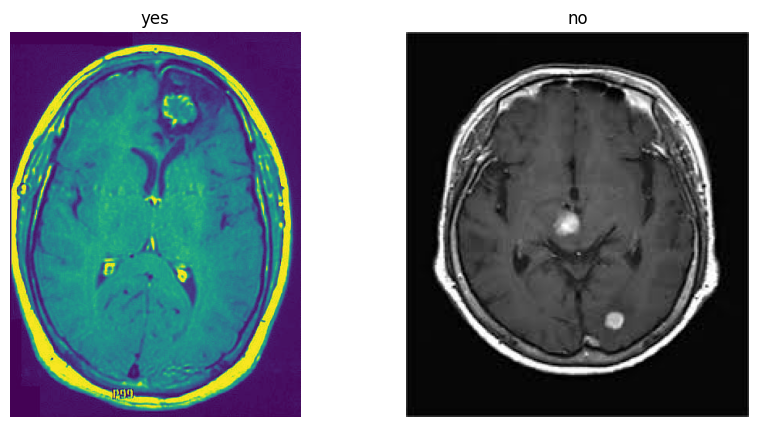

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = os.listdir(dataset_path)

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    image_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    image_path = os.path.join(dataset_path, cls, image_name)

    img = mpimg.imread(image_path)

    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

# Task 2: Data Preprocessing

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [24]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [25]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [26]:
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)

print("\nClass Labels:")
print(train_generator.class_indices)

Training Images : 203
Validation Images : 50

Class Labels:
{'no': 0, 'yes': 1}


In [27]:
images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32,)


# Task 3: Model Development

In [28]:
# Build the CNN Model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

print("CNN Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


In [29]:
# Display Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile the CNN Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [31]:
# Train the CNN Model

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 996ms/step - accuracy: 0.6847 - loss: 0.5969 - val_accuracy: 0.7400 - val_loss: 0.5273
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7783 - loss: 0.4984 - val_accuracy: 0.7600 - val_loss: 0.5369
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 899ms/step - accuracy: 0.8177 - loss: 0.4789 - val_accuracy: 0.7400 - val_loss: 0.5296
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8473 - loss: 0.4621 - val_accuracy: 0.7000 - val_loss: 0.5368
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8177 - loss: 0.4133 - val_accuracy: 0.7800 - val_loss: 0.5020
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8621 - loss: 0.3615 - val_accuracy: 0.7800 - val_loss: 0.5503
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8571 - loss: 0.3156 - val_accuracy: 0.8200 - val_loss: 0.5004
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8916 - loss: 0.2859 - val_accuracy: 0.8000 - val_loss: 0.4949
Epoch 9/1

# Task 4: Model Evaluation

In [32]:
# Evaluate the trained model

test_loss, test_accuracy = model.evaluate(validation_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.8000 - loss: 0.4224
Test Loss : 0.42242732644081116
Test Accuracy : 0.800000011920929


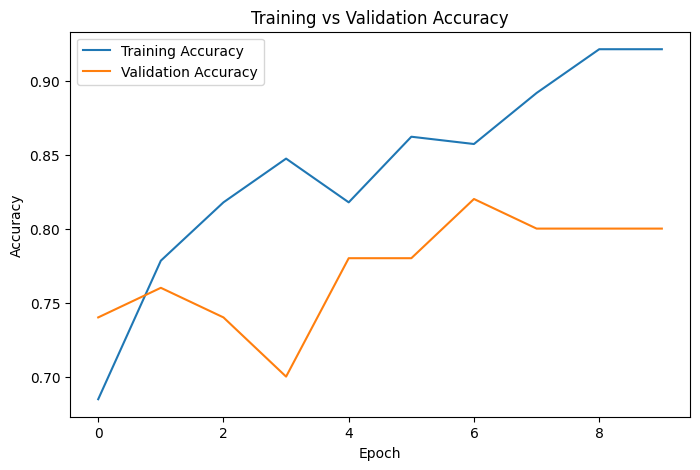

In [33]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

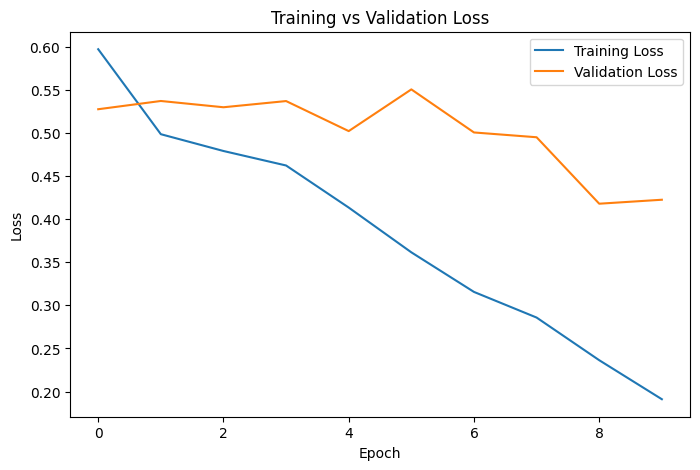

In [34]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


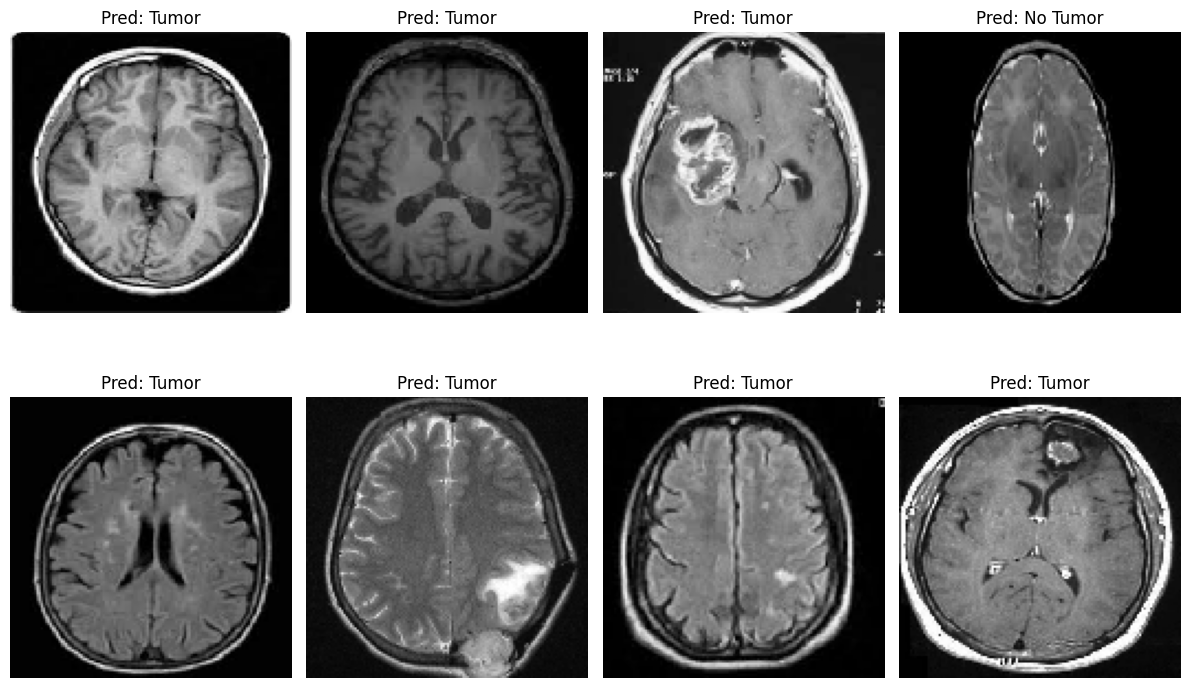

In [35]:
# Display predictions on sample images

images, labels = next(validation_generator)

predictions = model.predict(images)
predicted_labels = (predictions > 0.5).astype(int)

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(f"Pred: {'Tumor' if predicted_labels[i][0] == 1 else 'No Tumor'}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

1. The CNN model successfully learned to distinguish MRI images with tumors from normal MRI images.

2. The training and validation accuracy increased over the epochs, while the loss decreased, indicating effective learning.

3. A few images may still be misclassified because of similarities in MRI scans, image quality, or limited training samples.

# Task 5: Conclusion

The Convolutional Neural Network (CNN) model was successfully developed to detect brain tumors from MRI images. The dataset was preprocessed by normalizing the images and splitting them into training and validation sets. The CNN learned important visual features and achieved good classification accuracy for distinguishing between tumor and non-tumor images. The results show that deep learning techniques such as CNNs are effective for medical image classification tasks. However, the model's performance depends on the quality and quantity of the training data, and it may not generalize well to unseen MRI images from different sources. Further improvements can be achieved by using data augmentation, transfer learning, and larger datasets.